In [2]:
import pandas as pd

# Load the datasets
df_order_details = pd.read_csv('/content/order_details.csv')
df_orders = pd.read_csv('/content/orders.csv')

# Merge the order details and orders data on 'order.uid'
df_combined = pd.merge(df_order_details, df_orders, on='order.uid', how='inner')

# Select a smaller subset of data (first 1000 rows for testing)
df_subset = df_combined.head(1000)

# Display the first few rows of the subset
df_subset.head()

/tmp/ipython-input-1087572865.py:4: DtypeWarning: Columns (10,13) have mixed types. Specify dtype option on import or set low_memory=False.
  df_order_details = pd.read_csv('/content/order_details.csv')
/tmp/ipython-input-1087572865.py:5: DtypeWarning: Columns (5,11) have mixed types. Specify dtype option on import or set low_memory=False.
  df_orders = pd.read_csv('/content/orders.csv')


,item.uid,order.uid,item.date,product.uid,product.dynamicPricing,item.amount,item.discount,product.type,item.zoneName,product.durationHours,...,createdAtTime,paymentGateway,paymentBrand,pickup,pickupComplete,source,tenant,paymentAttempts,timeZone,clientInfo
0,rWzvRD0hXOShtjTzx5Ca,4y9zqqvldfqr9n2xnu,2024-07-05,OwhliJmMeSCILiMFiKTp,False,59.5,True,rental~bike,Bormio,12.0,...,2024-07-01 19:41:44,stripe,visa,False,False,website,snowit_esterno,2,NaN,"{""browser"":{""major"":""126"",""name"":""Chrome"",""ver..."
1,mmWAugpNnPVHRcePWiiH,termljwsr2gecnzwks,2024-12-27,form:PO9LFLX23J2024,False,0.0,False,hotel~coupon,Pontedilegno-Tonale,NaN,...,2024-07-01 18:34:12,discount,NaN,False,False,website,snowit_esterno,1,NaN,"{""browser"":{""major"":""126"",""name"":""Chrome"",""ver..."
2,bShIBhXedPkDTmZpmczI,ko8axscf5grobnz9in,2024-07-02,9oNSf7M6J7BNWakW2otU,False,26.0,False,food,Bardonecchia,4.0,...,2024-07-01 16:08:26,discount,NaN,False,False,website,snowit_esterno,1,NaN,"{""browser"":{""major"":""126"",""name"":""Chrome"",""ver..."
3,axrCVxzH7eVW2EbaKHho,ko8axscf5grobnz9in,2024-07-02,9oNSf7M6J7BNWakW2otU,False,26.0,False,food,Bardonecchia,4.0,...,2024-07-01 16:08:26,discount,NaN,False,False,website,snowit_esterno,1,NaN,"{""browser"":{""major"":""126"",""name"":""Chrome"",""ver..."
4,axrCVxzH7eVW2EbaKHho,ko8axscf5grobnz9in,2024-07-02,9oNSf7M6J7BNWakW2otU,False,-26.0,False,food,Bardonecchia,4.0,...,2024-07-01 16:08:26,discount,NaN,False,False,website,snowit_esterno,1,NaN,"{""browser"":{""major"":""126"",""name"":""Chrome"",""ver..."


In [3]:
basket_data = df_subset.pivot_table(index='order.uid', columns='product.uid', values='item.amount', aggfunc='sum')

basket_data = basket_data.applymap(lambda x: 1 if x > 0 else 0)

basket_data.head()


/tmp/ipython-input-2747887829.py:3: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  basket_data = basket_data.applymap(lambda x: 1 if x > 0 else 0)


product.uid,09KHDlLTyWpqnThEVW2Q,0B1Iz7rBQysYBJLygaKJ,0UIsHmok6cOUn7MlKlGe,12V4uFndLWcNZNeYQCC0,13LtQHon1YYiQbqNXpq8,171uSVa7CRuzc1VCeR0r,1N5Ue4JoG3UCXGCzWA4z,1pk0AIq8DqnA1rxM5l9S,2ICq4sWmRb7y8gMP4skG,2mx6OQd4dk1B0ruQri25,...,x80fed40uJ4ctoxaH8vB,xKnoyHUW1v2yUvAfBQ8U,xPxawqIIXdzxdfaYQM1A,xmQEvrzjlNH7UnPFB1p3,xuCm0qQTFRgnrOYTpxGA,y07PYhMLLGBjPbkqiMDJ,yQlhUOf4Unscbyb9K7Rc,yRMfxi4yRyfskOLRwZoH,z1g2LhWX3b9VLD57nqUi,zWpUCrMHijq1wRFmE71f
order.uid,,,,,,,,,,,,,,,,,,,,,
0214tuvadtm210y0p7,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
0fmwbnklbl63p9kvyn,0,0,0,0,1,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
0fpjzvrnqftiga06fv,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
0fvwbivqlhni0rfbly,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
0hfcns7wmxkepyhfbv,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [4]:
from mlxtend.frequent_patterns import apriori, association_rules

frequent_itemsets = apriori(basket_data, min_support=0.05, use_colnames=True)

rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1.0)

print(rules.head(10))


              antecedents             consequents  antecedent support  \
0  (KcSn5TI4hlXOKj9iQ8k5)  (vqnsyreizkOIvLDdNlUQ)            0.053672   
1  (vqnsyreizkOIvLDdNlUQ)  (KcSn5TI4hlXOKj9iQ8k5)            0.161017   

   consequent support   support  confidence      lift  representativity  \
0            0.161017  0.053672    1.000000  6.210526               1.0   
1            0.053672  0.053672    0.333333  6.210526               1.0   

   leverage  conviction  zhangs_metric   jaccard  certainty  kulczynski  
0   0.04503         inf       0.886567  0.333333   1.000000    0.666667  
1   0.04503    1.419492       1.000000  0.333333   0.295522    0.666667  


/usr/local/lib/python3.12/dist-packages/mlxtend/frequent_patterns/fpcommon.py:161: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: Dep

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

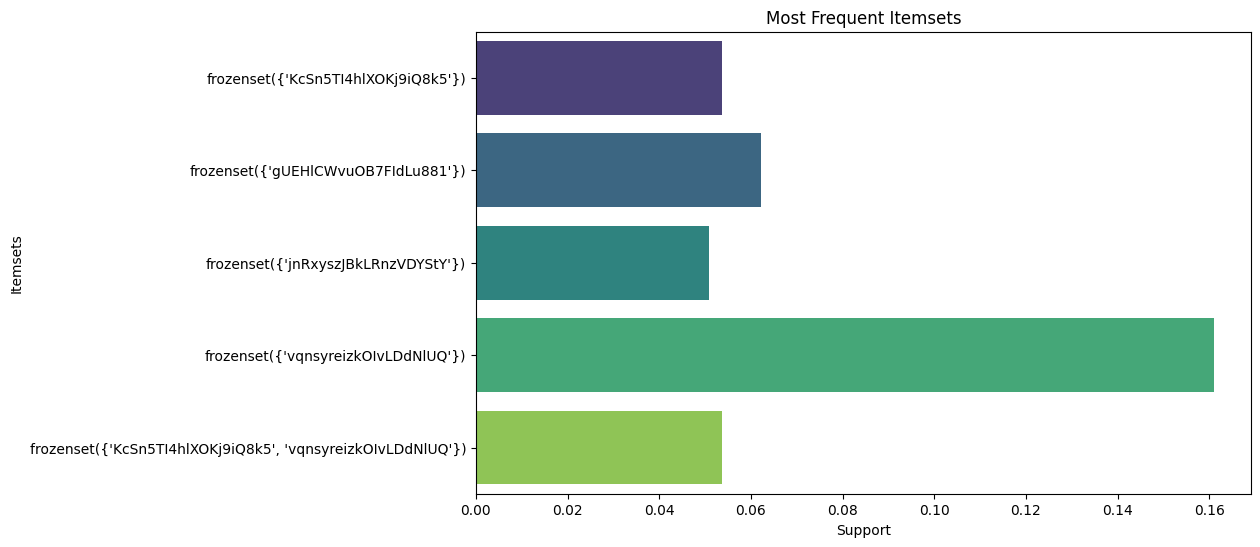

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


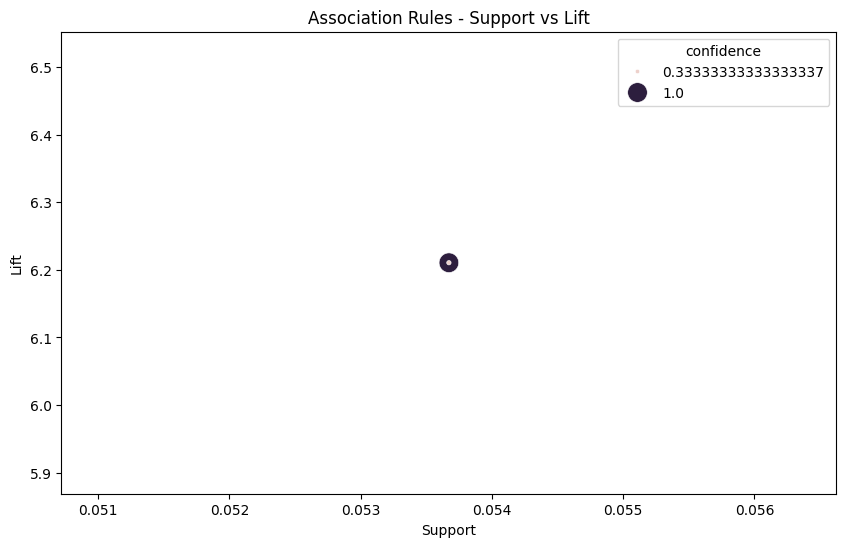

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

# Visualize the most frequent itemsets (bar plot)
plt.figure(figsize=(10,6))
sns.barplot(x='support', y='itemsets', data=frequent_itemsets, palette='viridis')
plt.title('Most Frequent Itemsets')
plt.xlabel('Support')
plt.ylabel('Itemsets')
plt.show()

# Visualize the association rules (scatter plot of support vs lift)
plt.figure(figsize=(10,6))
sns.scatterplot(x='support', y='lift', data=rules, hue='confidence', size='confidence', sizes=(10, 200))
plt.title('Association Rules - Support vs Lift')
plt.xlabel('Support')
plt.ylabel('Lift')
plt.show()
